# Only used to do postprocessing of `PM4Sand` from FLAC9

## Data generated by `PM4Sand` FLAC Element Driver

In [1]:
import os, glob, math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
from itertools import chain

In [2]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.ticker import AutoMinorLocator
import matplotlib.ticker as ticker
plt.rcParams['figure.dpi'] = 200

In [3]:
#from CRRModels import CRR_SPT_IB_2014
from processor import get_full_data_flac9_pm4sand
from processor import CDSSprocessor

In [4]:
#inputDir = os.path.join(os.getcwd(), 'PM4Silt', 'Cyclic DSS')
inputDir = os.path.join(os.getcwd(), 'PM4Sand', 'Cyclic DSS')
inputDir

'c:\\Users\\Zxu\\GitDoc\\FLAC_PM4Sand_Silt_plotter\\PM4Sand\\Cyclic DSS'

In [5]:
Project_ID = 'Test'
soil_unit = 'Test'

In [6]:
G0 = 510
Dr = 0.63
hp0 = 0.80
pA = 2116
CSR_target = 0.206
CSR_list = [CSR_target/1.4, CSR_target/1.2, CSR_target, CSR_target*1.2, CSR_target*1.5]

In [7]:
liq_criteria = 'SA'
cycles_to_liq_list = []
dfs_list = []
xlsx_files =  glob.glob(os.path.join(inputDir, '*.csv'))
for index, filename in enumerate(xlsx_files):
    if 'CSR' in filename:
        xlsx_files.pop(index)
files_sorted = sorted(xlsx_files, key=lambda x: float(x.split('_')[-1].split('.')[0]), reverse=True)
display(files_sorted)
for filepath in files_sorted:
    df = get_full_data_flac9_pm4sand(filepath)
    df_out = df.copy()
    print(f'{filepath=}')
    p = CDSSprocessor(
        csr_data=df[' CSR'],
        strain_data=df['Shear strain'],
        cycles_data=df['Cycle num'],
        ru_data=df[' ru'],
        thres_strain=3.0,
        criteria=liq_criteria
        )
    if liq_criteria == 'SA':
        cycles_to_liq = round(p.cycle_sa,1)
    else:
        cycles_to_liq = round(p.cycle_da,1)
    print(f'Cycles to Liquefy/Strain Softening = {cycles_to_liq}')

    #df = df[df['Cycle num'] <= np.ceil(cycles_to_liq)+5].copy()
    dfs_list.append(df_out)
    cycles_to_liq_list.append(cycles_to_liq)
cycles_to_liq_list

['c:\\Users\\Zxu\\GitDoc\\FLAC_PM4Sand_Silt_plotter\\PM4Sand\\Cyclic DSS\\cyclic_DSS_5.csv',
 'c:\\Users\\Zxu\\GitDoc\\FLAC_PM4Sand_Silt_plotter\\PM4Sand\\Cyclic DSS\\cyclic_DSS_4.csv',
 'c:\\Users\\Zxu\\GitDoc\\FLAC_PM4Sand_Silt_plotter\\PM4Sand\\Cyclic DSS\\cyclic_DSS_3.csv',
 'c:\\Users\\Zxu\\GitDoc\\FLAC_PM4Sand_Silt_plotter\\PM4Sand\\Cyclic DSS\\cyclic_DSS_2.csv',
 'c:\\Users\\Zxu\\GitDoc\\FLAC_PM4Sand_Silt_plotter\\PM4Sand\\Cyclic DSS\\cyclic_DSS_1.csv']

filepath='c:\\Users\\Zxu\\GitDoc\\FLAC_PM4Sand_Silt_plotter\\PM4Sand\\Cyclic DSS\\cyclic_DSS_5.csv'
Cycles to Liquefy/Strain Softening = 3.3
filepath='c:\\Users\\Zxu\\GitDoc\\FLAC_PM4Sand_Silt_plotter\\PM4Sand\\Cyclic DSS\\cyclic_DSS_4.csv'
Cycles to Liquefy/Strain Softening = 7.3
filepath='c:\\Users\\Zxu\\GitDoc\\FLAC_PM4Sand_Silt_plotter\\PM4Sand\\Cyclic DSS\\cyclic_DSS_3.csv'
Cycles to Liquefy/Strain Softening = 15.3
filepath='c:\\Users\\Zxu\\GitDoc\\FLAC_PM4Sand_Silt_plotter\\PM4Sand\\Cyclic DSS\\cyclic_DSS_2.csv'
Cycles to Liquefy/Strain Softening = 33.8
filepath='c:\\Users\\Zxu\\GitDoc\\FLAC_PM4Sand_Silt_plotter\\PM4Sand\\Cyclic DSS\\cyclic_DSS_1.csv'
Cycles to Liquefy/Strain Softening = 65.5


[3.3, 7.3, 15.3, 33.8, 65.5]

In [8]:
def custom_ceil(value, step=0.1):
    return math.ceil(value / step) * step

def pm4sand_plot(dfs_list: list, max_csr: float = CSR_target*1.5) -> None:
    font = {'sans-serif' : 'Arial',
            'family' : 'sans-serif',
        'size' : 16}
    plt.rc('font', **font)
    max_csr = custom_ceil(max_csr, 0.1)
    fig = plt.figure(figsize=(25.5, 20))
    gs = gridspec.GridSpec(5, 5, wspace=0.2, hspace=0.25,
                        width_ratios=[1, 1, 1, 1, 1], height_ratios=[1, 1, 1, 1, 1])
    fig.subplots_adjust(left=0.1, right=0.95,
                bottom=0.1, top=0.95,
                hspace=1.0, wspace=0.4)
    # Function to create subplots
    def create_subplot(row, col):
        return fig.add_subplot(gs[row, col])

    # Create subplots
    ax = [[None]*5 for _ in range(5)]

    for i in range(4):
        for j in range(5):
            ax[i][j] = create_subplot(i, j)

    #set row labels
    row_names = ['CSR', 'Number of Cycles', 'CSR', 'Number of Cycles']
    for index, row_name in enumerate(row_names):
        ax[index][0].set_ylabel(row_name)

    #set column labels
    column_names = [
        r'$\gamma_{xy}$ (%)',
        r'$\gamma_{xy}$ (%)', 
        r"$\sigma'_{v}$ / $\sigma'_{vo}$",
        r"Pore Pressure Ratio, $r_{u}$"
        ]

    for i in range(5):
        for index, column_name in enumerate(column_names):
            ax[index][i].set_xlabel(column_name)
            if column_name == r'$\gamma_{xy}$ (%)':
                ax[index][i].set_xlim(-6, 6)

    # CRR-N figure
    ax[4][0] = fig.add_subplot(gs[4, 0:2])
    ax[4][0].set_xscale('log')
    ax[4][0].set_xlim(1, 100)
    ax[4][0].set_xlabel('Number of Cycles')
    ax[4][0].set_ylabel('CRR')
    ax[4][0].grid(which='minor')
    ax[4][0].grid(which='major')
    ax[4][0].yaxis.set_major_locator(ticker.MultipleLocator(0.1))  
    ax[4][0].yaxis.set_minor_locator(ticker.MultipleLocator(0.2))

    #plot data
    kwag = {'color': 'k',
            'ls': '-',
            'lw': 2.5}
    for index, df in enumerate(dfs_list):
        strain_xy = df[' Shear strain (%)'].to_numpy()
        CSR = df[' CSR'].to_numpy()
        vert_eff_ratio = df[' Vert eff stress ratio'].to_numpy()
        cycles = df['Cycle num'].to_numpy()
        ru = df[' ru'].to_numpy()
        ax[0][index].set_title(f'Test-{index+1} CSR = {round(CSR.max(),2)}')
        ax[0][index].plot(strain_xy, CSR, **kwag)
        ax[1][index].plot(strain_xy, cycles, **kwag)
        ax[2][index].plot(vert_eff_ratio, CSR, **kwag)
        ax[3][index].plot(ru, cycles, **kwag)

    for ax0 in chain(ax[2][:], ax[3][:]):
        ax0.set_xlim(0, 1)
    
    for ax0 in ax[2][:]:
        ax0.set_ylim(-max_csr, max_csr)
    # Notes
    props = dict(boxstyle='round', facecolor='white', alpha=0.9)
    textstr0 = '\n'.join((
        r'Primary Parameter:',
        r'G$_{o}$ = %.0f' % (G0),
        r'h$_{po}$ = %.2f' % (hp0),
        r'D$_{r}$ = %.2f' % (Dr),
        r'p$_{A}$ = %.1f psf' % (pA)))

    textstr1 = '\n'.join((
        r'Secondary (1): (0.0 as default)',
        r'h$_{o}$ = %.1f' % (0.0),
        r'e$_{max}$ = %.1f' % (0.8),
        r'e$_{min}$ = %.1f' % (0.5),
        r'n$^{b}$ = %.1f' % (0.0),
        r'n$_{d}$ = %.1f' % (0.0),
        r'C$_{Z}$ = %.1f' % (0.0),
        r'C$_{E}$ = %.1f' % (0.0),
        r'z$_{max}$ = %.1f' % (0.0),
        ))
    
    textstr2 = '\n'.join((
        r'Secondary (2): (0.0 as default)',
        r'C$_{DR}$ = %.1f' % (0.0),
        r'C$_{Kaf}$ = %.1f' % (0.0),
        r'C$_{GD}$ = %.1f' % (0.0),
        r'$\phi_{cv}$ = %.1f' % (0.0),
        r'Q = %.1f' % (0.0),
        r'R = %.1f' % (0.0),
        r'm = %.1f' % (0.0),
        r'A$_{d0}$ = %.1f' % (0.0),
        r'F$_{sed, min}$ = %.1f' %(0.0),
        r'P$_{sed, o}$ = %.1f' %(0.0)
        ))
    
    textstr3 =  '\n'.join((f'Project ID: {Project_ID}',
                        f'Soil Unit: {soil_unit}',
                        'Soil Model: $PM4Sand$'))
    ax[4][0].text(1.08, 0.97, textstr0, transform=ax[4][0].transAxes, fontsize=20,
        verticalalignment='top', bbox=props)

    ax[4][0].text(1.42, 0.97, textstr1, transform=ax[4][0].transAxes, fontsize=20,
        verticalalignment='top', bbox=props)

    ax[4][0].text(1.92, 0.97, textstr2, transform=ax[4][0].transAxes, fontsize=20,
            verticalalignment='top', bbox=props)
    
    ax[4][0].text(1.03, 0.3, textstr3, transform=ax[4][0].transAxes, fontsize=21,
            verticalalignment='top')
    cycles_to_liq_list_sorted = sorted(cycles_to_liq_list, reverse=True)
    CSR_list_sorted = sorted(CSR_list, reverse=False)
    ax[4][0].axhline(y=CSR_target, ls='--', color='red')
    ax[4][0].axvline(x=15, ls='--', color='red')
    ax[4][0].set_ylim(0, max(CSR_list_sorted)*1.1)
    ax[4][0].plot(cycles_to_liq_list_sorted, CSR_list_sorted, 's--k',label='Simulation')
    ax[4][0].legend(loc='best')
    plt.show()

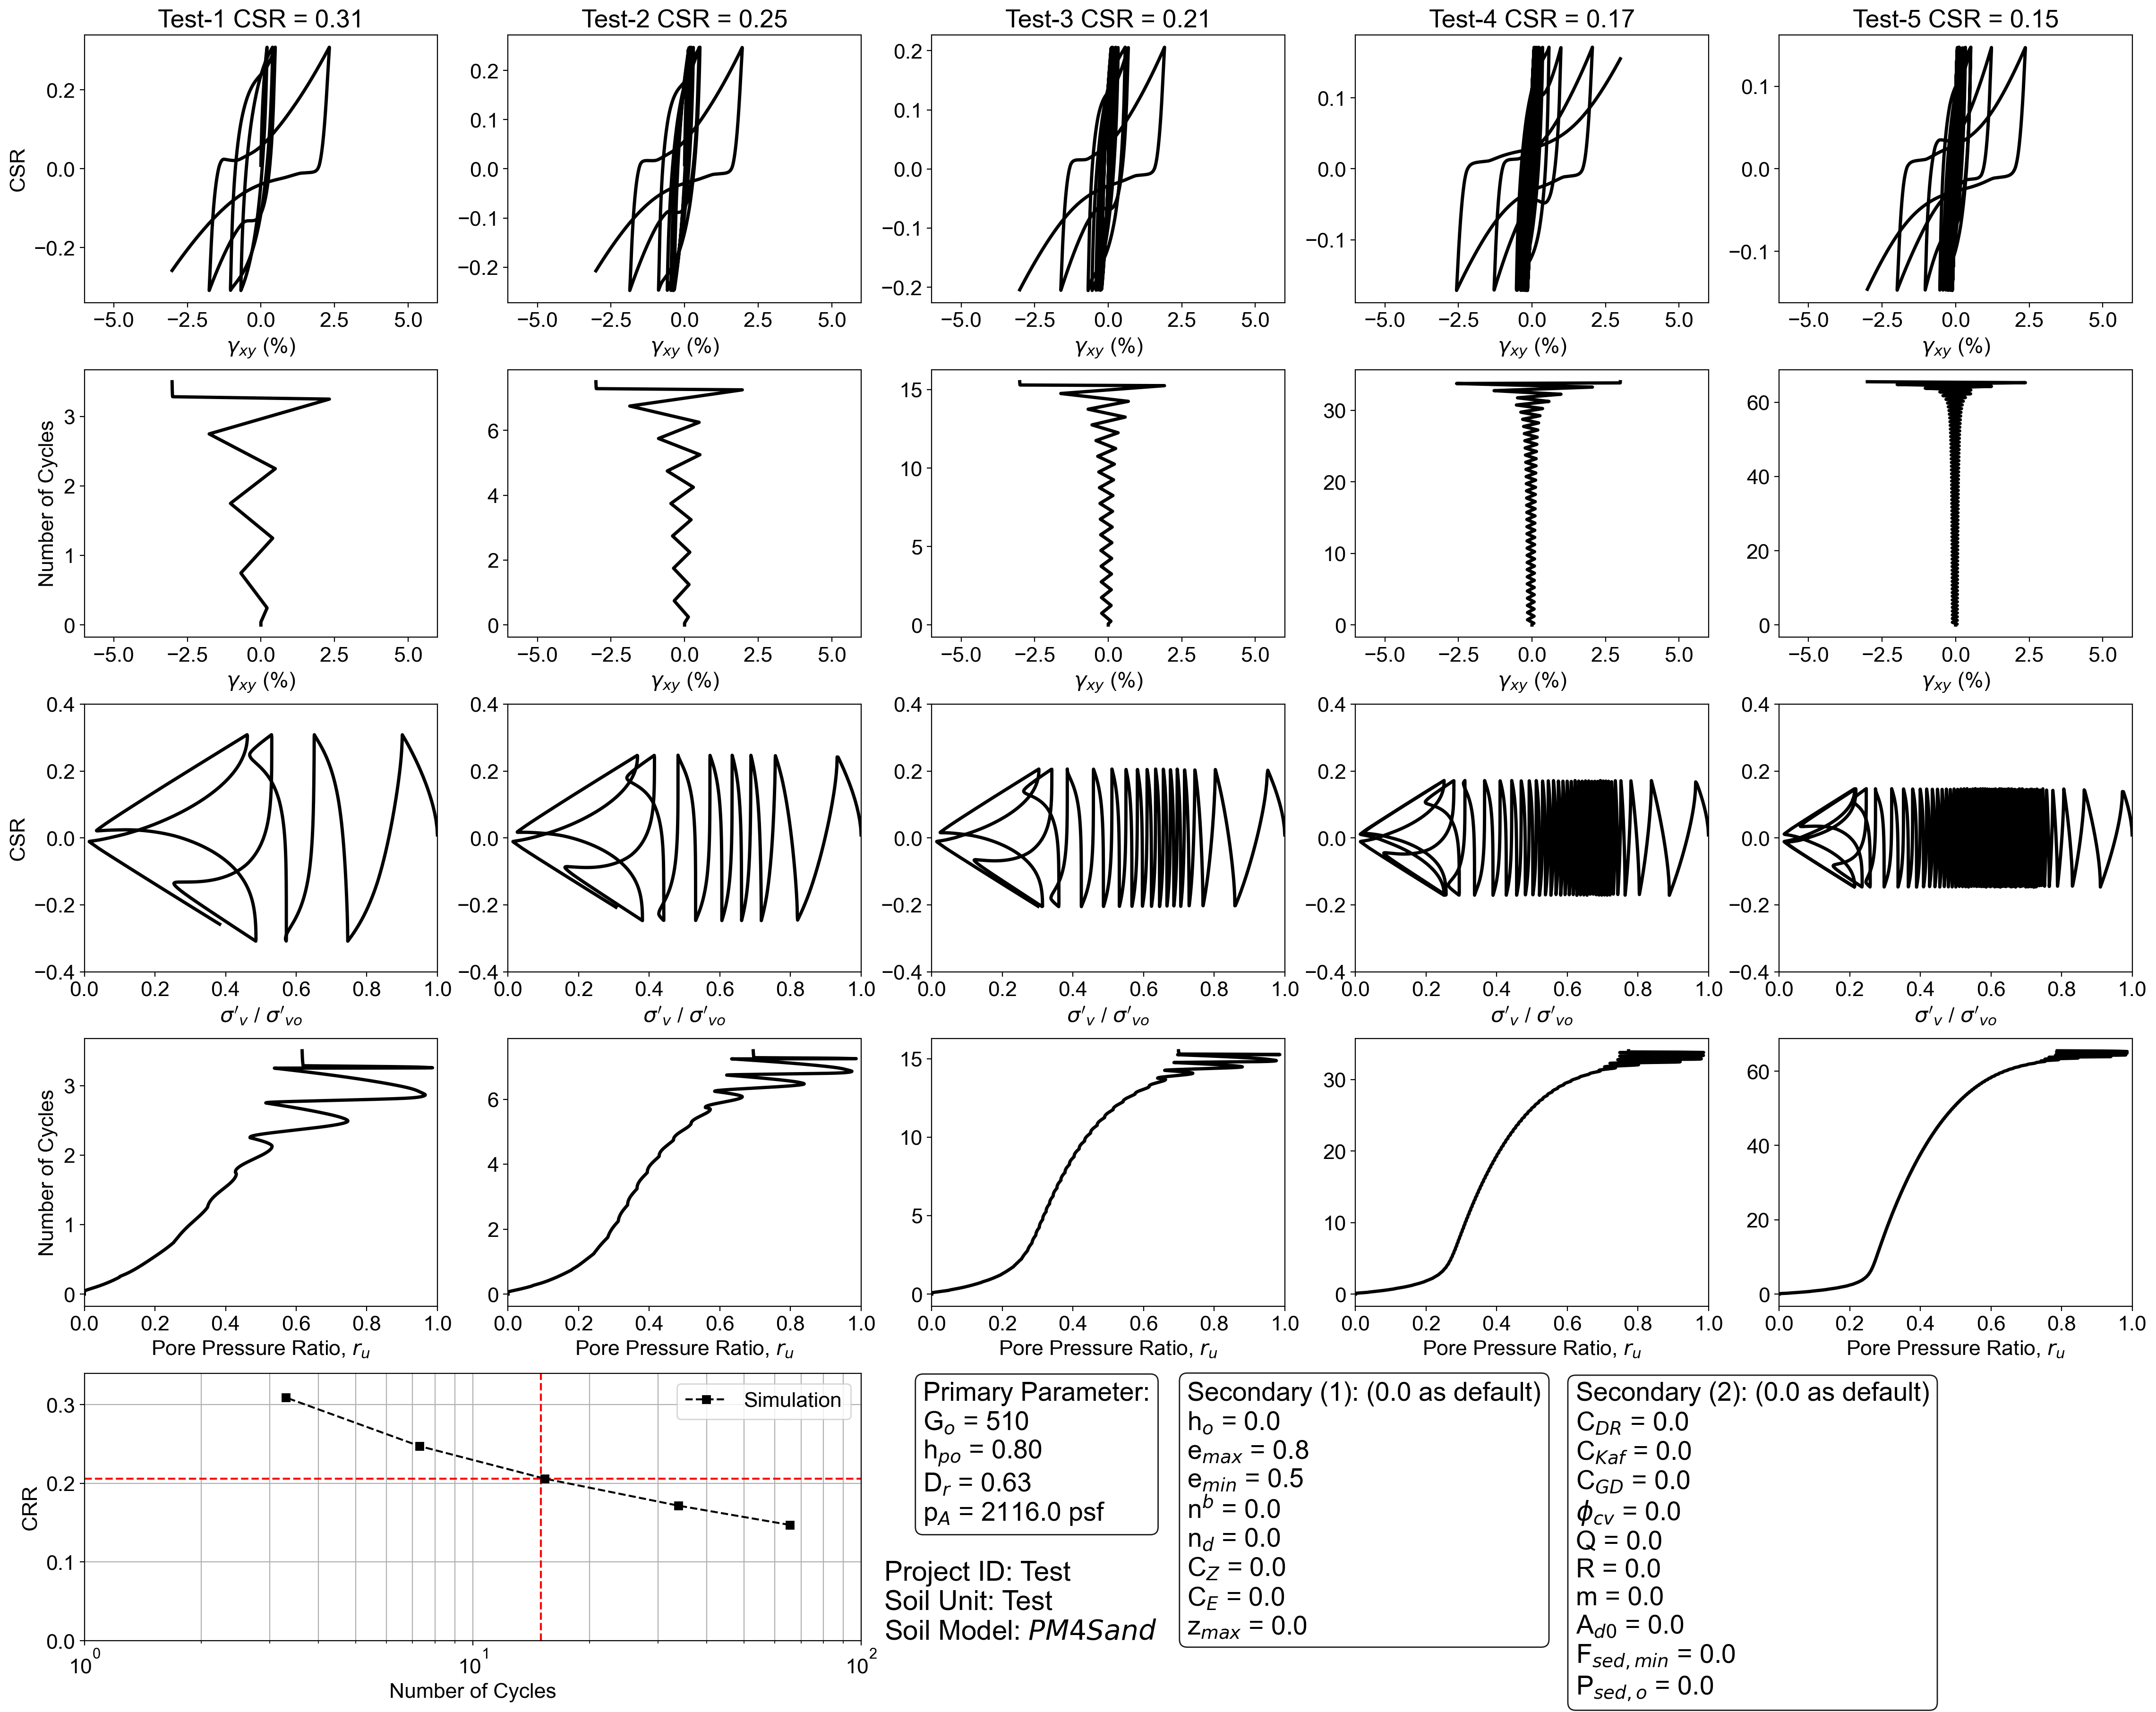

In [9]:
pm4sand_plot(dfs_list)